## Forward Problem Description

We are solving the following second-order ordinary differential equation (ODE):

$\frac{d^2u}{dx^2} + u = \sin(3x)$

with the boundary conditions:

1. $u(0) + \frac{du}{dx}(0) = -1$
2. $\frac{du}{dx}(\frac{\pi}{2}) = 1$

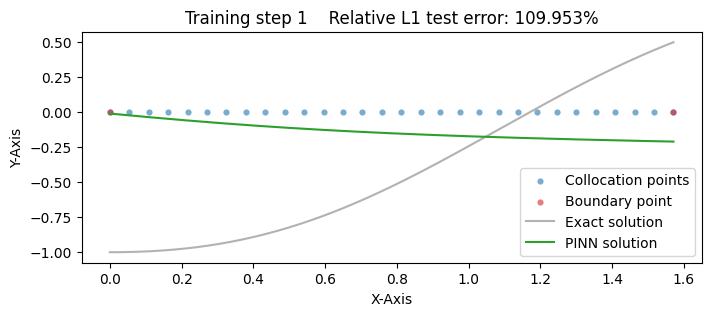

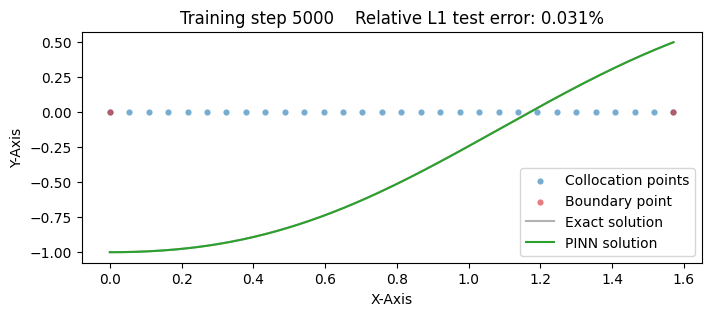

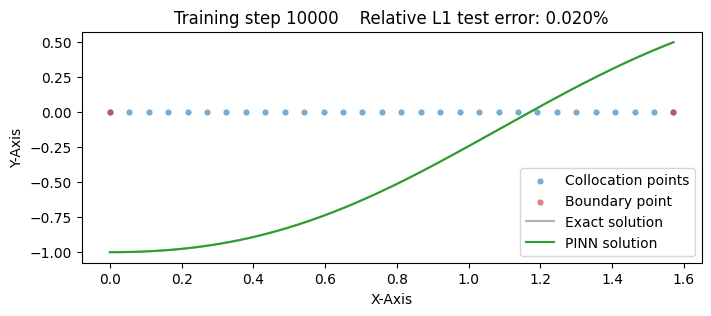

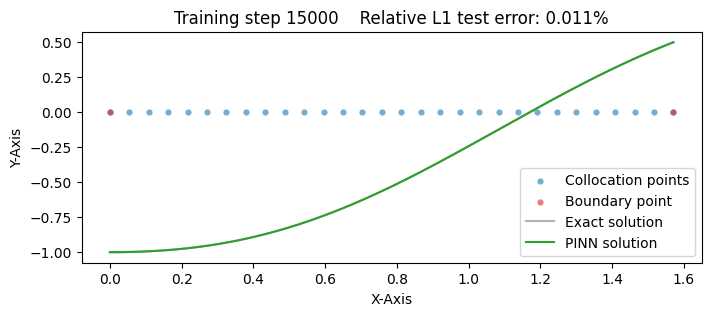

Total training time: 43.389890909194946 seconds


In [1]:
import time

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def exact_solution(x):
    cos = torch.cos(x)
    sin = torch.sin(x)
    sin3 = torch.sin(3*x)
    u = -cos + 3*sin/8 - sin3/8
    return u

class FCN(nn.Module):
    "Defines a fully-connected network in PyTorch"
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

    torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,32,3)

# define boundary points, for the boundary loss
# TODO # (1, 1)
x_boundary_1 = torch.tensor(0.,requires_grad=True).reshape(-1,1)
pi = torch.pi
x_boundary_2 = torch.tensor(pi/2,requires_grad=True).reshape(-1,1)

# define training points over the entire domain, for the physics loss
x_physics = torch.linspace(0,pi/2,30, requires_grad=True).reshape(-1,1)

# train the PINN
x_test = torch.linspace(0,pi/2,300).view(-1,1)
u_exact = exact_solution(x_test)
optimiser = torch.optim.Adam(pinn.parameters(),lr=1e-3)
start = time.time()
for i in range(15000):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above using the following hyperparameters
    lambda1,lambda2, lambda3 = 1e1, 1e1,1

    # compute boundary loss
    u_1 = pinn(x_boundary_1)
    du_1dx = torch.autograd.grad(u_1,x_boundary_1,torch.ones_like(u_1),create_graph=True)[0]
    u_2  = pinn(x_boundary_2)
    du_2dx = torch.autograd.grad(u_2,x_boundary_2,torch.ones_like(u_2),create_graph=True)[0]
    loss1 = torch.mean((u_1 + du_1dx + 1)**2)
    loss2 = torch.mean((du_2dx-1)**2)

    # compute physics loss
    u = pinn(x_physics)
    dudx = torch.autograd.grad(u, x_physics, torch.ones_like(u), create_graph=True)[0]
    d2udx2 = torch.autograd.grad(dudx, x_physics, torch.ones_like(dudx), create_graph=True)[0]
    sin3 = torch.sin(3*x_physics)
    loss3 = torch.mean((d2udx2 + u - sin3)**2)


    # backpropagate joint loss, take optimiser step
    loss = lambda1*loss1 + lambda2*loss2 + lambda3*loss3
    loss.backward()
    optimiser.step()

    # plot the result as training progresses
    if (i+1)%5000 == 0 or i==0:
        u = pinn(x_test).detach()
        test_error = torch.mean(torch.abs(u-u_exact)/u_exact.std())
        plt.figure(figsize=(8,3))
        plt.scatter(x_physics.detach()[:,0], torch.zeros_like(x_physics)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
        plt.scatter(x_boundary_1.detach()[:,0], 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point")
        plt.scatter(x_boundary_2.detach()[:,0], 0, s=20, lw=0, color="tab:red", alpha=0.6)
        plt.plot(x_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
        plt.plot(x_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.xlabel("X-Axis")
        plt.ylabel("Y-Axis")
        plt.title(f"Training step {i+1}    Relative L1 test error: {test_error:.3%}")
        plt.legend()
        plt.show()

print(f"Total training time: {time.time()-start} seconds")

## Inverse Problem

In this inverse problem, we aim to discover the unknown parameter $\alpha$ in the differential equation:

$\frac{d^2u}{dx^2} + u = \sin(\alpha x)$

We will use noisy observational data $u_{obs}(x)$ and the same boundary conditions as the forward problem to estimate $\alpha$.

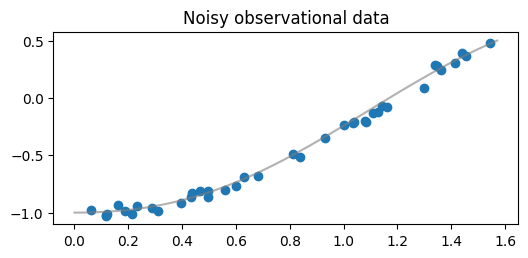

In [2]:
## Inverse Problem

torch.manual_seed(123)
pi = torch.pi
x_obs = torch.rand(40).view(-1,1) * pi/2
u_obs = exact_solution(x_obs) + 0.04*torch.randn_like(x_obs)
x_test = torch.linspace(0,pi/2,300).view(-1,1)
u_exact = exact_solution(x_test)

plt.figure(figsize=(6,2.5))
plt.title("Noisy observational data")
plt.scatter(x_obs[:,0], u_obs[:,0])
plt.plot(x_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.show()

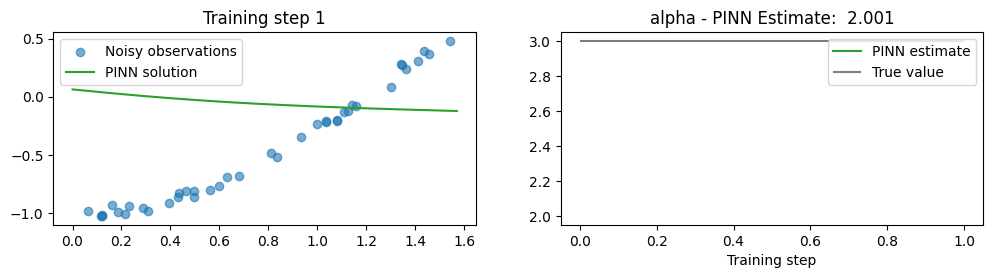

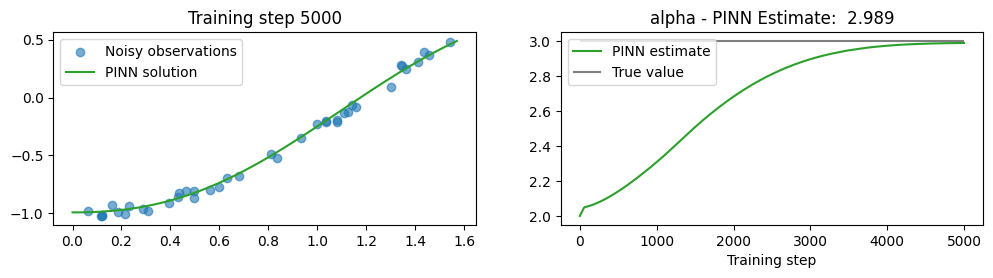

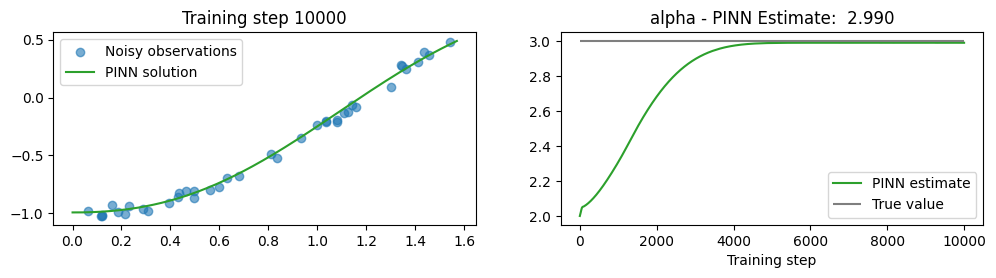

Estimated value of alpha is :  2.9897282123565674


In [3]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,32,3)
pi = torch.pi

# define training points over the entire domain, for the physics loss
x_physics = torch.linspace(0,pi/2,50).view(-1,1).requires_grad_(True)# (50, 1)

# train the PINN
x_test = torch.linspace(0,pi/2,300).view(-1,1)
u_exact = exact_solution(x_test)

# Boundary points
x_boundary_1 = torch.tensor(0.,requires_grad=True).reshape(-1,1)
x_boundary_2 = torch.tensor(pi/2,requires_grad=True).reshape(-1,1)

# treat alpha as a learnable parameter, add it to optimiser
alpha = torch.nn.Parameter(torch.tensor(2.))
optimiser = torch.optim.Adam(list(pinn.parameters()) + [alpha],lr=1e-3)
alphas = []
start = time.time()
for i in range(10000):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters
    lambda1,lambda2,lambda3,lambda4 = 1e2,1e1,1e1,1e1

    # compute physics loss
    u = pinn(x_physics)# (50, 1)
    dudt = torch.autograd.grad(u, x_physics, torch.ones_like(x_physics), create_graph=True)[0]# (50, 1)
    d2udt2 = torch.autograd.grad(dudt, x_physics, torch.ones_like(dudt), create_graph=True)[0]# (50, 1)
    sinalpha = torch.sin(alpha*x_physics)
    loss1 = torch.mean((d2udt2 + u - sinalpha)**2)

    # compute data loss
    # TODO
    u = pinn(x_obs)
    loss2 = torch.mean((u-u_obs)**2)

    # compute boundary loss

    u_1 = pinn(x_boundary_1)
    du_1dx = torch.autograd.grad(u_1,x_boundary_1,torch.ones_like(u_1),create_graph=True)[0]
    u_2  = pinn(x_boundary_2)
    du_2dx = torch.autograd.grad(u_2,x_boundary_2,torch.ones_like(u_2),create_graph=True)[0]
    loss3 = torch.mean((u_1 + du_1dx + 1)**2)
    loss4 = torch.mean((du_2dx -1)**2)


    # backpropagate joint loss, take optimiser step
    loss = lambda1*loss1 + lambda2*loss2+lambda3*loss3+lambda4*loss4
    loss.backward()
    optimiser.step()

    # record mu value
    alphas.append(alpha.item())

    # plot the result as training progresses
    if (i+1)%5000 == 0 or i==0:
        u = pinn(x_test).detach()
        plt.figure(figsize=(12,2.5))

        plt.subplot(1,2,1)
        plt.scatter(x_obs[:,0], u_obs[:,0], label="Noisy observations", alpha=0.6, color="tab:blue")
        plt.plot(x_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i+1}")
        plt.legend()

        plt.subplot(1,2,2)
        plt.title(f"alpha - PINN Estimate: {alpha.item() : .3f}")
        plt.plot(alphas, label="PINN estimate", color="tab:green")
        plt.hlines(3, 0, len(alphas), label="True value", color="tab:grey")
        plt.xlabel("Training step")
        plt.legend()

        plt.show()

print("Estimated value of alpha is : ", alpha.item())
print(f"Total training time: {time.time()-start} seconds")